# Quintic SV Reproduction And SPX Deep Surrogate

Ce notebook est la source principale du projet.

Il suit le schema suivant :

1. charger les inputs publies dans le papier ;
2. reconstruire explicitement le facteur gaussien et la volatilite quintique ;
3. pricer VIX analytiquement ;
4. pricer SPX par Monte Carlo de reference ;
5. entrainer un surrogate deep learning sur des labels Monte Carlo ;
6. reutiliser ce surrogate pour remplacer le moteur SPX sur les scenarios du papier.

## Organisation du code

Les fonctions importantes sont volontairement reparties par role :

- `quintic_sv/configs.py` : inputs publies dans le papier ;
- `quintic_sv/factor_process.py` : simulation du facteur gaussien `X_t` ;
- `quintic_sv/polynomial_volatility.py` : construction de `p(X_t)` et `\sigma_t` ;
- `quintic_sv/vix_analytic.py` : pricing VIX analytique ;
- `quintic_sv/spx_monte_carlo.py` : pricing SPX Monte Carlo de reference ;
- `quintic_sv/spx_deep_learning.py` : dataset, MLP Numpy, entrainement et inference ;
- `quintic_sv/paper_workflow.py` : orchestration des figures du papier ;
- `quintic_sv/plots.py` : tracés lisibles et honnetes.

In [1]:
import sys  # Donne acces a sys.path pour que le notebook puisse importer le package local.
from pathlib import Path  # Manipule les chemins de fichiers de maniere robuste et portable.

import matplotlib.pyplot as plt  # Trace toutes les figures de diagnostic et les figures de style article.
import numpy as np  # Gere les tableaux, les calculs vectorises et les resumes numeriques.
from IPython.display import display  # Force l'affichage explicite des figures dans le notebook.


def locate_prep_root() -> Path:  # Trouve le dossier PREP meme si le notebook est ouvert depuis un autre dossier.
    cwd = Path.cwd().resolve()  # Part du dossier de travail courant du kernel du notebook.
    candidates = [cwd, *cwd.parents]  # Teste le dossier courant puis tous ses dossiers parents.
    for candidate in candidates:  # Inspecte chaque dossier parent possible un par un.
        if (candidate / 'quintic_sv').exists():  # Cas ou le kernel s'execute deja dans PREP.
            return candidate  # Retourne immediatement la racine PREP.
        if (candidate / 'PREP' / 'quintic_sv').exists():  # Cas ou le kernel s'execute un niveau au-dessus de PREP.
            return candidate / 'PREP'  # Retourne la racine PREP trouvee dans ce dossier parent.
    raise FileNotFoundError('Impossible de localiser le dossier PREP contenant quintic_sv.')  # Arrete clairement l'execution si la racine du projet est introuvable.


ROOT = locate_prep_root()  # Resout le chemin absolu de la racine du projet utilisee par le notebook.
if str(ROOT) not in sys.path:  # Verifie si le chemin du package local est deja disponible pour les imports Python.
    sys.path.insert(0, str(ROOT))  # Ajoute la racine du projet au debut de sys.path pour prioriser les imports locaux.

from quintic_sv.configs import (  # Importe les scenarios publies utilises dans tout le notebook.
    paper_constant_h_spline_scenario,  # Parametres publies utilises pour les Figures 1 et 2.
    paper_parametric_medium_scenario,  # Parametres publies utilises pour la Figure 4.
    paper_parametric_short_scenario,  # Parametres publies utilises pour la Figure 3.
    paper_time_dependent_scenario,  # Parametres publies utilises pour les Figures 5 a 7.
)
from quintic_sv.curves import evaluate_forward_variance_curve  # Evalue la courbe de variance forward d'entree xi_0(t).
from quintic_sv.factor_process import simulate_factor_paths_for_model  # Simule le facteur gaussien latent X_t.
from quintic_sv.paper_workflow import (  # Importe les fonctions de haut niveau utilisees pour reconstruire les resultats de l'article.
    build_paper_figure_bundle,  # Calcule tous les smiles necessaires a un scenario publie.
    build_spx_strike_grid,  # Construit la grille de strikes SPX utilisee pour une maturite.
    build_vix_strike_percent_grid,  # Construit les pourcentages de strike VIX utilises dans le pricing analytique.
)
from quintic_sv.plots import (  # Importe les fonctions de trace utilisees plus loin dans le notebook.
    plot_forward_curve,  # Trace la courbe de variance forward xi_0(t).
    plot_joint_smiles,  # Trace les smiles SPX et VIX cote a cote.
    plot_spx_monte_carlo_vs_surrogate,  # Compare le smile SPX Monte Carlo avec le smile du surrogate profond.
    plot_time_dependent_h,  # Trace la courbe H(t) dependante du temps.
)
from quintic_sv.polynomial_volatility import build_volatility_paths_from_factor_paths  # Construit sigma_t une fois X_t simule.
from quintic_sv.spx_deep_learning import (  # Importe tous les outils de deep learning utilises pour remplacer le SPX Monte Carlo.
    generate_spx_surrogate_dataset,  # Genere les donnees enseignant Monte Carlo pour le surrogate.
    price_spx_smile_with_surrogate,  # Remplace le pricing SPX Monte Carlo par le surrogate entraine.
    save_spx_surrogate_model,  # Save the trained surrogate to disk.
    train_spx_surrogate_model,  # Train the MLP surrogate on Monte Carlo labels.
)
from quintic_sv.spx_monte_carlo import price_spx_smile_with_monte_carlo  # Use the reference SPX Monte Carlo pricer.
from quintic_sv.utils import generate_antithetic_normals  # Generate Gaussian shocks with antithetic variance reduction.
from quintic_sv.vix_analytic import price_vix_smile_analytic  # Use the analytic VIX pricing formula of the model.

plt.rcParams['figure.figsize'] = (8, 3)  # Set a compact default size for plots shown in the notebook.

quick_budget_scale = 0.20  # Reduce numerical budgets so the notebook remains fast to rerun interactively.
print('PREP root =', ROOT)  # Show the resolved project root used for imports and outputs.
print('quick_budget_scale =', quick_budget_scale)  # Show the default fast-run budget scale used below.

PREP root = /home/louis.savary/Bureau/PRRE_24-main/PREP
quick_budget_scale = 0.2


## 1. Inputs publies dans le papier

Les fonctions de `configs.py` ne calibrent rien : elles fournissent les inputs publies par les auteurs.

L'idee est donc honnete et simple :

- si on injecte les inputs du papier ;
- alors le code doit retomber sur les sorties du papier par calcul.

In [2]:
constant_experiment = paper_constant_h_spline_scenario()  # Charge le scenario publie a H constant avec spline utilise pour les Figures 1 et 2.
time_dependent_experiment = paper_time_dependent_scenario()  # Charge le scenario publie a H dependant du temps utilise pour les Figures 5 a 7.

constant_experiment  # Affiche toute la structure pour inspecter exactement les donnees publiees.

ExperimentInput(name='figure_1_and_2', spot=100.0, model_parameters=ConstantHModelParameters(rho=-0.6842593, h_value=-0.03583785, epsilon=0.019230769230769232, polynomial=QuinticPolynomialCoefficients(alpha0=0.59069477, alpha1=0.99999991, alpha3=0.28927803, alpha5=0.05491437)), forward_curve=SplineForwardVarianceCurve(node_times=array([0.        , 0.02601012, 0.03696174, 0.05065128, 0.06297186,
       0.07529244, 0.08898198, 0.09993361, 0.10540942, 0.11636105,
       0.1355264 , 0.16427442, 0.21218779, 0.25736326]), node_values=array([0.00950134, 0.00799541, 0.00514354, 0.01079057, 0.02396814,
       0.00793446, 0.01301627, 0.02776016, 0.00222057, 0.01965447,
       0.01085834, 0.02437202, 0.01278166, 0.01881186])), smile_grid=SmileGridSettings(spx_maturities=array([0.03011698, 0.08213721, 0.18343977, 0.24093582]), vix_maturities=array([0.02464116, 0.06297186, 0.08213721, 0.15879861]), vix_log_moneyness_min=-0.1, vix_log_moneyness_max=1.0, vix_num_strikes=50), monte_carlo=MonteCarloSet

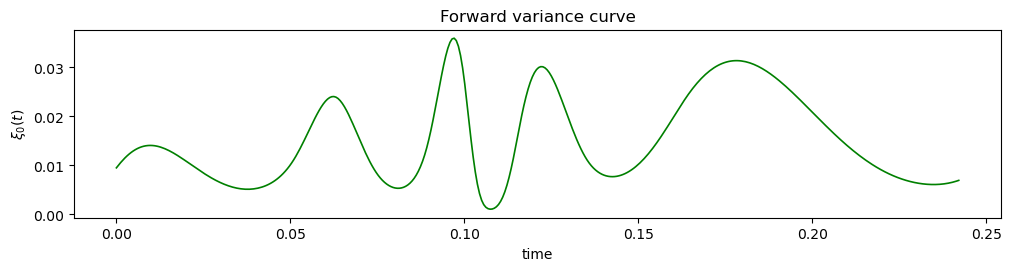

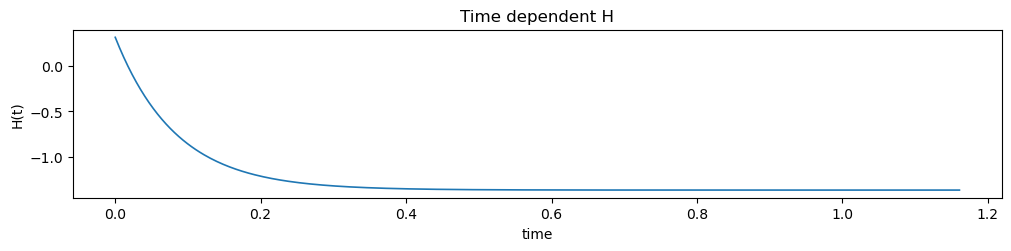

In [3]:
constant_bundle = build_paper_figure_bundle(constant_experiment, spx_engine='mc', budget_scale=quick_budget_scale)  # Calcule le scenario publie a H constant avec le moteur SPX Monte Carlo.
fig = plot_forward_curve(constant_bundle.forward_curve_trace)  # Trace xi_0(t), la courbe de variance forward utilisee comme entree du modele dans le scenario a H constant.
display(fig)  # Affiche la courbe de variance forward pour voir la structure par terme qui pilote le niveau de volatilite.
plt.close(fig)  # Ferme la figure apres affichage pour eviter un double rendu dans Jupyter.

time_dependent_bundle = build_paper_figure_bundle(time_dependent_experiment, spx_engine='mc', budget_scale=0.10)  # Calcule le scenario publie a H dependant du temps avec un petit budget pour aller plus vite.
if time_dependent_bundle.h_trace is not None:  # Verifie que ce scenario fournit bien une courbe H(t) avant de la tracer.
    fig = plot_time_dependent_h(time_dependent_bundle.h_trace)  # Trace H(t), la forme de rugosite ou de mean reversion variable dans le temps utilisee dans l'extension longue maturite.
    display(fig)  # Affiche la courbe H(t) pour voir comment le parametre evolue dans le temps.
    plt.close(fig)  # Ferme la figure apres affichage pour eviter les graphiques dupliques.

## 2. Facteur gaussien et volatilite quintique

Le coeur du modele est le facteur latent `X_t`. Une fois `X_t` simule, on construit

$$
p(X_t) = \alpha_0 + \alpha_1 X_t + \alpha_3 X_t^3 + \alpha_5 X_t^5
$$

puis

$$
\sigma_t = \sqrt{\xi_0(t)} \frac{p(X_t)}{\sqrt{\mathbb E[p(X_t)^2]}}.
$$

Les deux cellules suivantes montrent explicitement ces objets intermediaires sur le scenario constant `H`.

In [4]:
maturity_spx = float(constant_experiment.smile_grid.spx_maturities[1])  # Selectionne une maturite SPX publiee pour inspecter le mecanisme en detail.
normals = generate_antithetic_normals(n_steps=80, n_base_paths=400, seed=constant_experiment.monte_carlo.random_seed)  # Genere les chocs gaussiens pour la simulation du facteur latent avec couplage antithetique.

factor_simulation = simulate_factor_paths_for_model(constant_experiment.model_parameters, maturity_spx, normals)  # Simule le facteur gaussien latent X_t jusqu'a la maturite SPX choisie.
forward_variance = evaluate_forward_variance_curve(factor_simulation.times, constant_experiment.forward_curve)  # Evalue xi_0(t), la courbe de variance forward, sur la grille de temps de simulation.
volatility_paths = build_volatility_paths_from_factor_paths(  # Construit sigma_t a partir des trajectoires du facteur, du polynome p(X_t) et de la normalisation E[p(X_t)^2].
    constant_experiment.model_parameters.polynomial_vector(),  # Passe les coefficients du polynome quintique qui definissent p(x).
    factor_simulation.factor_paths,  # Passe les trajectoires simulees du facteur latent X_t.
    factor_simulation.factor_std,  # Passe l'ecart-type theorique de X_t a chaque instant.
    forward_variance,  # Passe la courbe de variance forward xi_0(t) evaluee sur la meme grille.
)

print('factor paths shape =', factor_simulation.factor_paths.shape)  # Affiche les dimensions du tableau simule de X_t : pas de temps x trajectoires.
print('forward variance shape =', forward_variance.shape)  # Affiche la dimension de la courbe xi_0(t) sur la grille de simulation.
print('volatility paths shape =', volatility_paths.shape)  # Affiche les dimensions du tableau sigma_t obtenu : pas de temps x trajectoires.

factor paths shape = (80, 800)
forward variance shape = (80,)
volatility paths shape = (80, 800)


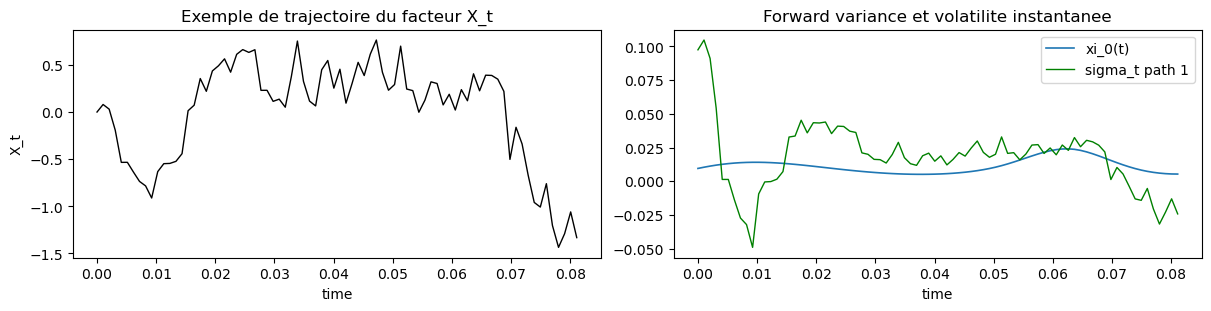

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3), constrained_layout=True)  # Cree une figure a deux panneaux : un panneau pour X_t et un panneau pour la variance ou la volatilite.
axes[0].plot(factor_simulation.times, factor_simulation.factor_paths[:, 0], color='black', linewidth=1.0)  # Trace une trajectoire exemple de X_t, le facteur gaussien latent qui pilote le modele de volatilite.
axes[0].set_title('Exemple de trajectoire du facteur X_t')  # Titre du panneau de gauche qui montre la trajectoire du facteur latent.
axes[0].set_xlabel('time')  # L'axe horizontal represente le temps jusqu'a maturite.
axes[0].set_ylabel('X_t')  # L'axe vertical represente la valeur du facteur gaussien latent.

axes[1].plot(factor_simulation.times, forward_variance, color='tab:blue', linewidth=1.2, label='xi_0(t)')  # Trace xi_0(t), la courbe de variance forward qui fixe le niveau de variance au cours du temps.
axes[1].plot(factor_simulation.times, volatility_paths[:, 0], color='green', linewidth=1.0, label='sigma_t path 1')  # Trace sigma_t sur une trajectoire simulee, c'est-a-dire la volatilite instantanee effectivement utilisee pour le pricing SPX.
axes[1].set_title('Forward variance et volatilite instantanee')  # Titre du panneau de droite qui compare xi_0(t) et une trajectoire de sigma_t.
axes[1].set_xlabel('time')  # L'axe horizontal represente de nouveau le temps.
axes[1].legend(loc='best')  # Indique quelle courbe est la variance forward deterministe et quelle courbe est la volatilite instantanee simulee.
display(fig)  # Affiche la figure de diagnostic a deux panneaux dans le notebook.
plt.close(fig)  # Ferme la figure apres affichage pour eviter un double affichage.

## 3. Pricing VIX analytique

La partie VIX ne repose pas sur un Monte Carlo : le papier montre que `VIX_T^2` reste polynomial en `X_T`.

On peut donc calculer le future VIX et les prix de calls VIX par integration gaussienne.

In [6]:
maturity_vix = float(constant_experiment.smile_grid.vix_maturities[1])  # Selectionne une maturite VIX publiee a calculer analytiquement.
vix_strike_percentages = build_vix_strike_percent_grid(constant_experiment)  # Construit la grille relative de strikes K / F utilisee pour le smile VIX.
vix_smile = price_vix_smile_analytic(  # Calcule analytiquement le smile VIX en utilisant la representation polynomiale de VIX_T^2.
    constant_experiment,  # Utilise comme entree le meme scenario publie a H constant.
    maturity_vix,  # Calcule la maturite VIX choisie.
    vix_strike_percentages,  # Utilise la grille publiee de pourcentages de strike VIX.
    quadrature_degree=160,  # Utilise un budget de quadrature moyen pour garder le notebook reactif.
    n_steps=120,  # Utilise une grille d'integration moyenne sur [T, T + 30/360].
)

print('VIX future =', round(float(vix_smile.future), 6))  # Affiche le future VIX implique par le modele pour cette maturite.
print('first VIX strikes =', np.round(vix_smile.strikes[:5], 4))  # Affiche les premiers strikes VIX en niveau absolu.
print('first VIX IV =', np.round(vix_smile.implied_volatility[:5], 6))  # Affiche les premieres volatilites implicites VIX du smile selon le modele.

VIX future = 11.670451
first VIX strikes = [10.5599 10.7996 11.0448 11.2955 11.552 ]
first VIX IV = [0.721139 0.777452 0.824564 0.872548 0.913492]


## 4. Pricing SPX Monte Carlo de reference

Ici on garde le moteur Monte Carlo comme **teacher**. C'est lui qui fournit les labels de reference pour le surrogate deep learning.

first SPX strikes = [77.8801 79.1195 80.3787 81.6579 82.9575]
first SPX IV = [0.350449 0.335384 0.320139 0.304692 0.28902 ]


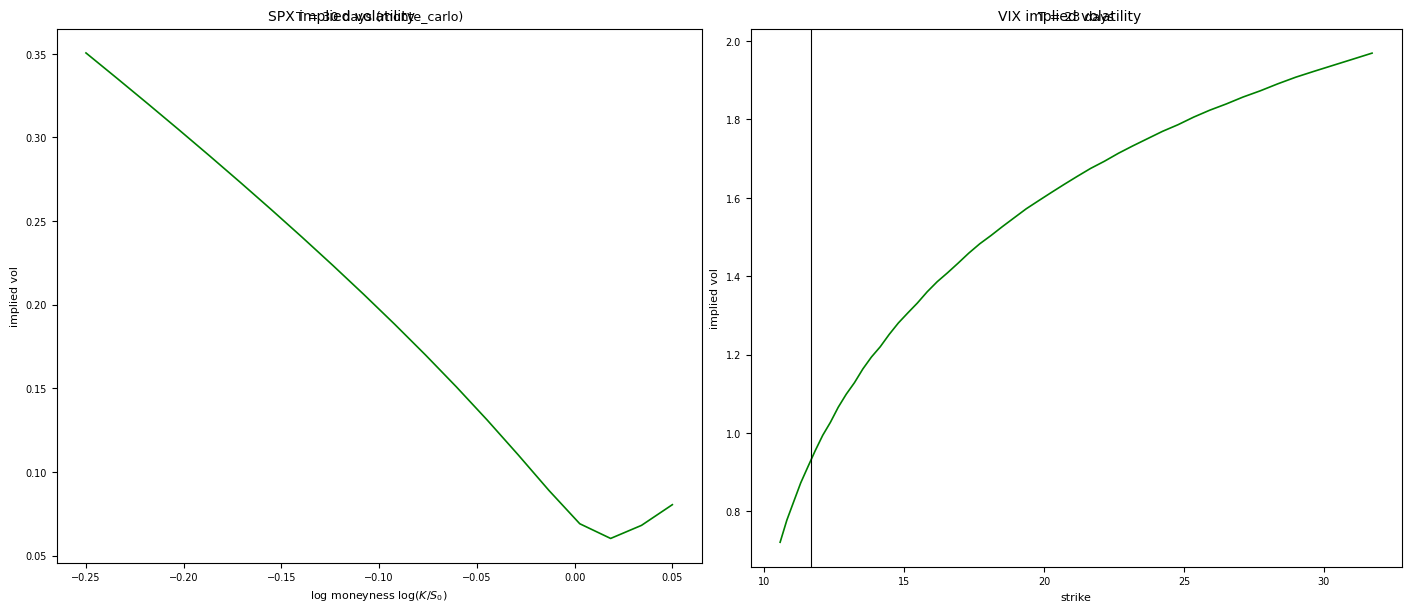

In [7]:
spx_strikes = build_spx_strike_grid(constant_experiment.spot, maturity_spx, strike_count=20)  # Construit la grille de strikes SPX a partir de la plage de log-moneyness de style article.
spx_smile_mc = price_spx_smile_with_monte_carlo(  # Calcule le smile SPX avec le moteur Monte Carlo de reference.
    constant_experiment,  # Utilise l'experience publiee a H constant comme entree du modele.
    maturity_spx,  # Calcule la maturite SPX choisie.
    spx_strikes,  # Utilise les strikes SPX construits sur la grille de style article.
    monte_carlo_settings=constant_bundle.experiment.monte_carlo,  # Reutilise le budget Monte Carlo attache au bundle de l'experience.
)

print('first SPX strikes =', np.round(spx_smile_mc.strikes[:5], 4))  # Affiche les premiers strikes SPX utilises dans le smile.
print('first SPX IV =', np.round(spx_smile_mc.implied_volatility[:5], 6))  # Affiche les premieres volatilites implicites SPX obtenues par Monte Carlo.
fig = plot_joint_smiles([spx_smile_mc], [vix_smile], orientation='side_by_side')  # Trace cote a cote le smile SPX issu du Monte Carlo et le smile VIX issu de la formule analytique.
display(fig)  # Affiche la figure conjointe SPX/VIX pour comparer les deux sorties sur une maturite chacune.
plt.close(fig)  # Close the figure after display to avoid duplicate rendering.

## 5. Entrainement du surrogate deep learning

Le surrogate est un MLP Numpy. Il prend en entree :

- les parametres du modele ;
- une representation echantillonnee de la courbe forward ;
- la maturite ;
- le log-moneyness.

Il apprend a predire le **prix SPX normalise** produit par le Monte Carlo teacher.

Les reglages ci-dessous sont volontairement legers pour que le notebook reste manipulable. Pour un travail plus serieux, augmente :

- `number_of_experiments` ;
- `teacher_base_paths` ;
- `epochs`.

In [8]:
dataset = generate_spx_surrogate_dataset(  # Genere un jeu de donnees supervise synthetique en utilisant Monte Carlo comme enseignant.
    number_of_experiments=24,  # Echantillonne 24 configurations de modele aleatoires pour generer les donnees d'entrainement.
    strikes_per_experiment=12,  # Calcule 12 strikes pour chaque configuration echantillonnee.
    teacher_steps=48,  # Utilise 48 pas de temps dans le Monte Carlo enseignant.
    teacher_base_paths=350,  # Utilise 350 trajectoires de base avant duplication antithetique dans l'enseignant.
    seed=0,  # Fixe la graine aleatoire pour rendre le jeu de donnees reproductible.
)
surrogate_model, history = train_spx_surrogate_model(  # Entraine le MLP Numpy surrogate sur les labels Monte Carlo generes.
    dataset,  # Utilise le jeu de donnees supervise qui vient d'etre genere.
    epochs=120,  # Execute 120 epoques d'optimisation.
    batch_size=128,  # Utilise des mini-lots de taille 128.
    learning_rate=3e-3,  # Utilise un taux d'apprentissage Adam de 0.003.
    seed=0,  # Fixe la graine aleatoire pour rendre reproductibles l'initialisation et le melange.
)

print('dataset shape =', dataset.features.shape)  # Affiche la taille de la matrice de features : echantillons x features.
print('final train loss =', history.train_loss[-1])  # Affiche la loss finale d'entrainement du surrogate.
print('final validation loss =', history.validation_loss[-1])  # Affiche la loss finale de validation du surrogate.

dataset shape = (288, 20)
final train loss = 0.0010114220586044122
final validation loss = 0.010120547382293246


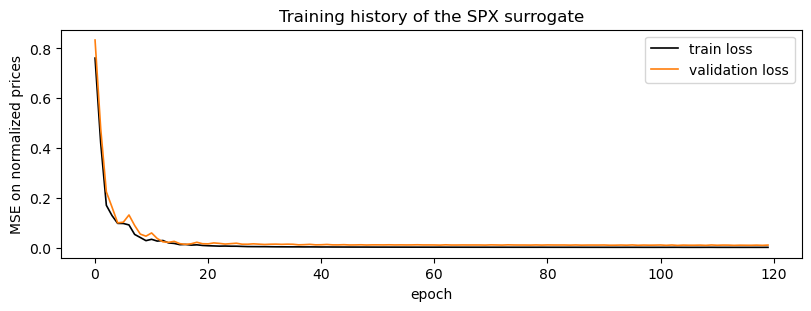

In [9]:
fig, ax = plt.subplots(figsize=(8, 3), constrained_layout=True)  # Cree une figure montrant les courbes d'apprentissage du MLP surrogate.
ax.plot(history.train_loss, color='black', linewidth=1.2, label='train loss')  # Trace la loss d'entrainement, c'est-a-dire la MSE sur l'echantillon d'entrainement au fil des epoques.
ax.plot(history.validation_loss, color='tab:orange', linewidth=1.2, label='validation loss')  # Trace la loss de validation, c'est-a-dire la MSE sur des echantillons de validation non vus au fil des epoques.
ax.set_title('Training history of the SPX surrogate')  # Titre expliquant que ce panneau suit l'optimisation du surrogate.
ax.set_xlabel('epoch')  # L'axe horizontal represente l'indice de l'epoque.
ax.set_ylabel('MSE on normalized prices')  # L'axe vertical represente l'erreur quadratique moyenne sur les prix SPX normalises par le spot.
ax.legend(loc='best')  # Indique quelle courbe correspond a la loss d'entrainement et quelle courbe correspond a la loss de validation.
display(fig)  # Affiche la figure de l'historique d'entrainement dans le notebook.
plt.close(fig)  # Ferme la figure apres affichage pour eviter un double affichage.

## 6. Remplacer le Monte Carlo SPX par le surrogate

On compare d'abord le smile SPX Monte Carlo contre le smile SPX produit par le MLP sur le scenario constant du papier.

first surrogate SPX IV = [nan nan nan nan nan]


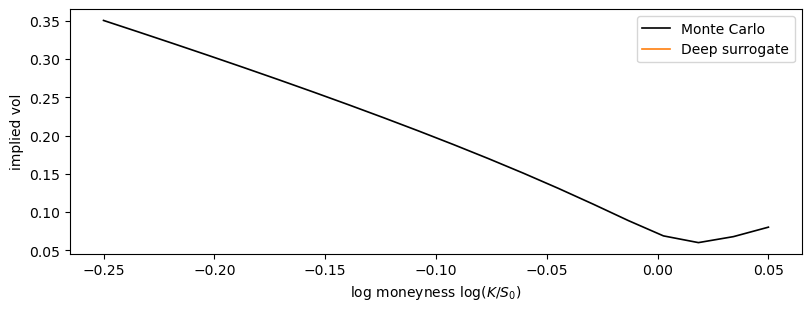

In [10]:
spx_smile_dl = price_spx_smile_with_surrogate(constant_experiment, maturity_spx, spx_strikes, surrogate_model)  # Calcule de nouveau le meme smile SPX, mais cette fois avec le surrogate profond entraine a la place du Monte Carlo.
print('first surrogate SPX IV =', np.round(spx_smile_dl.implied_volatility[:5], 6))  # Affiche les premieres volatilites implicites SPX du surrogate pour une verification numerique rapide.
fig = plot_spx_monte_carlo_vs_surrogate(spx_smile_mc, spx_smile_dl)  # Trace sur les memes axes le smile SPX Monte Carlo et le smile SPX du surrogate pour les comparer directement.
display(fig)  # Affiche la figure de comparaison montrant a quel point le surrogate suit la reference Monte Carlo.
plt.close(fig)  # Close the figure after display to avoid duplicate rendering.

## 7. Rejouer les scenarios du papier avec le surrogate

Le moteur VIX reste analytique. Seul le moteur SPX est remplace par le surrogate deep learning.

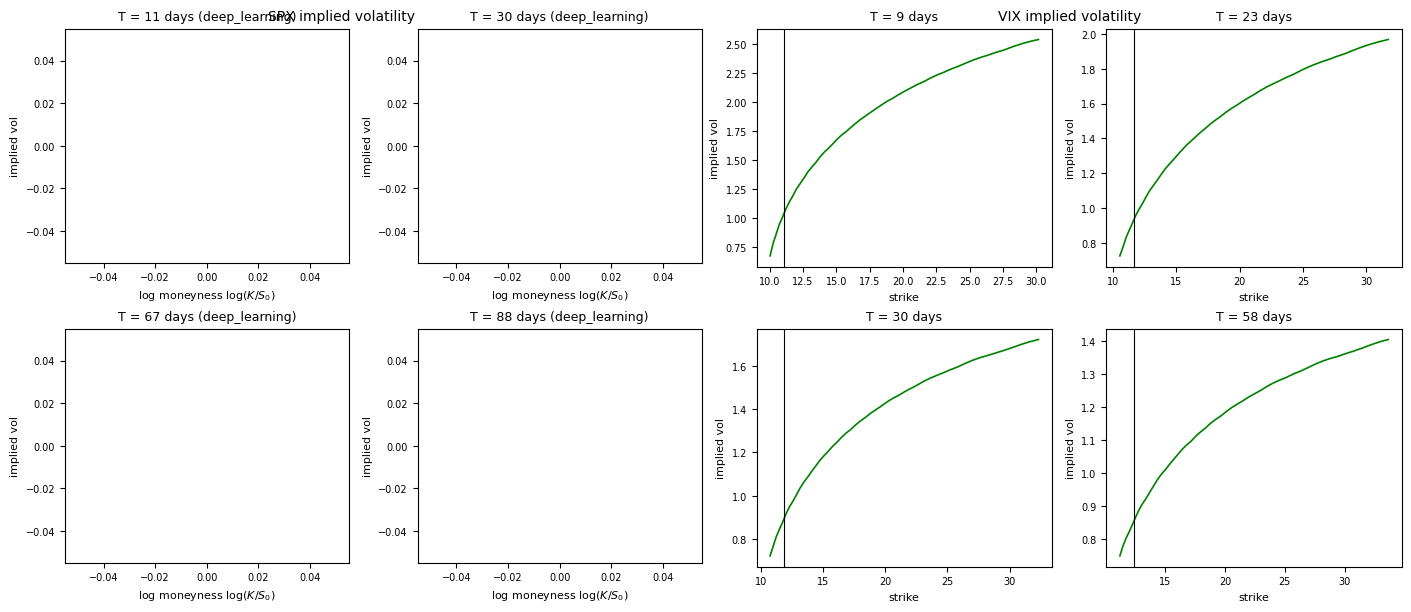

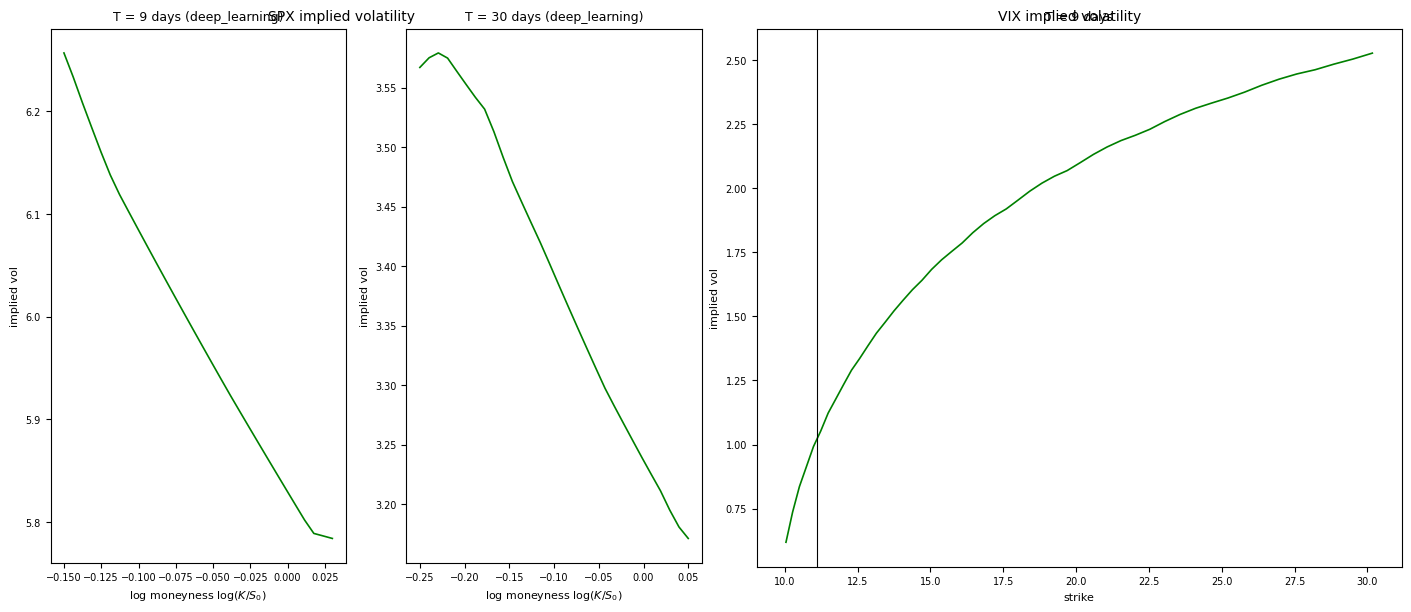

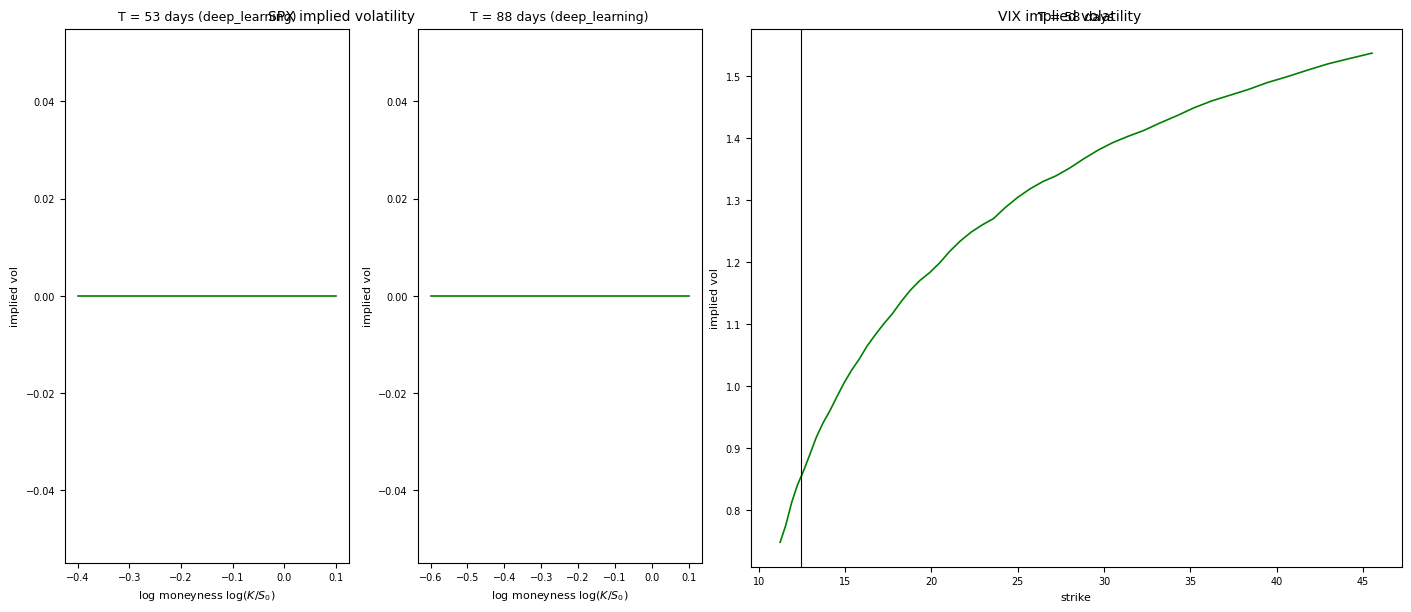

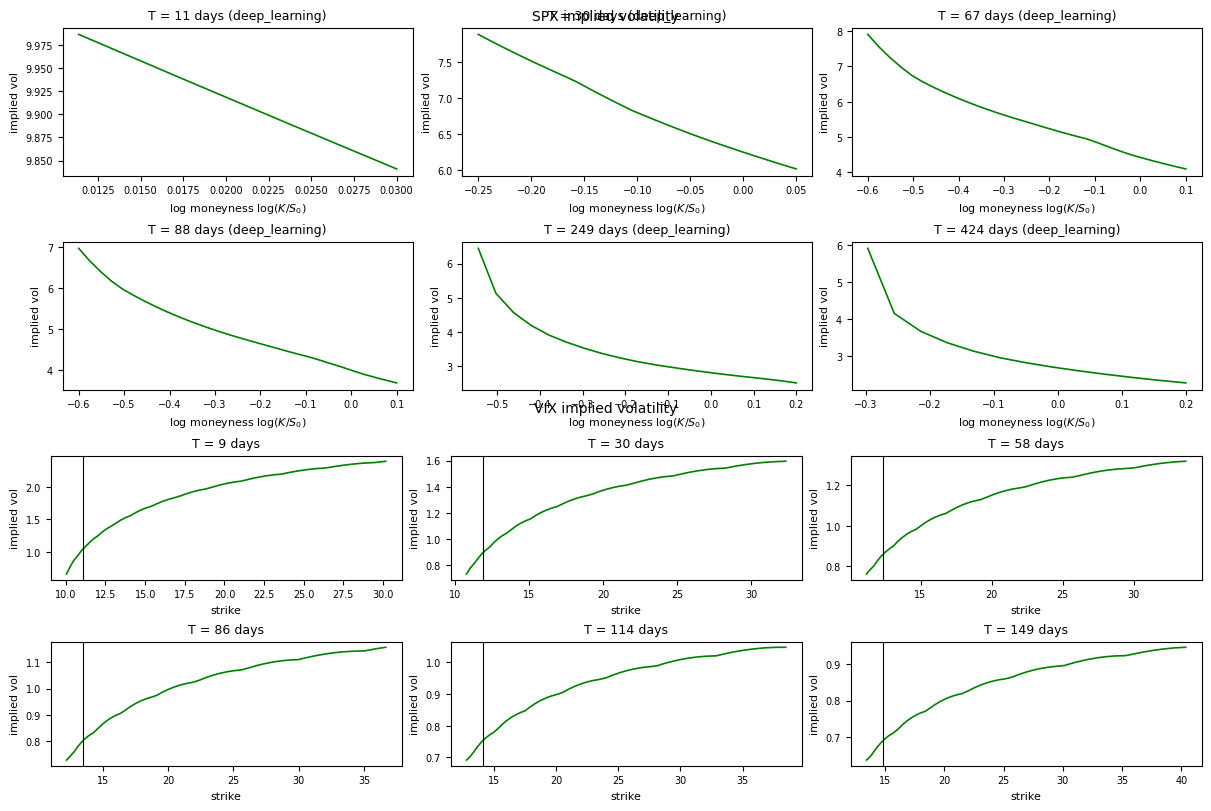

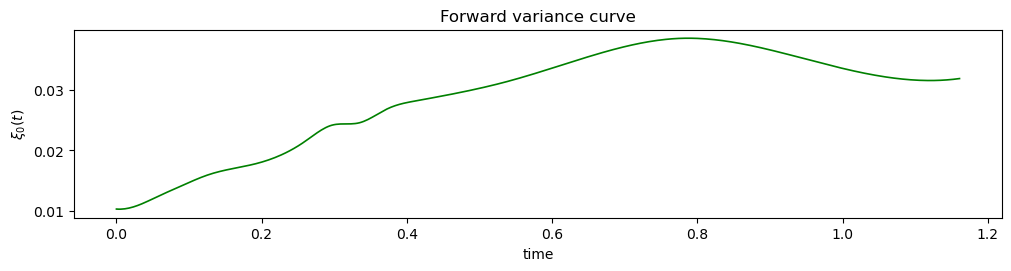

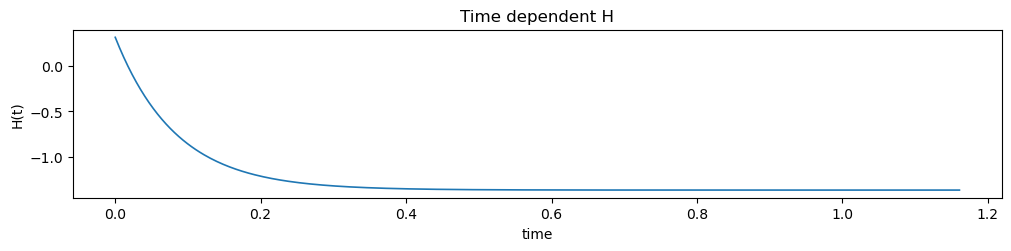

In [11]:
bundle_constant_dl = build_paper_figure_bundle(  # Reconstruit le scenario d'article a H constant en utilisant le moteur SPX deep learning.
    paper_constant_h_spline_scenario(),  # Utilise les parametres publies des Figures 1 et 2.
    spx_engine='dl',  # Remplace le moteur SPX Monte Carlo par le surrogate.
    surrogate_model=surrogate_model,  # Injecte le modele surrogate entraine.
    budget_scale=quick_budget_scale,  # Conserve le budget rapide du notebook.
)
bundle_short_dl = build_paper_figure_bundle(  # Reconstruit le scenario parametrique court de l'article en utilisant le moteur SPX deep learning.
    paper_parametric_short_scenario(),  # Utilise les parametres publies de la Figure 3.
    spx_engine='dl',  # Remplace le moteur SPX Monte Carlo par le surrogate.
    surrogate_model=surrogate_model,  # Injecte le modele surrogate entraine.
    budget_scale=quick_budget_scale,  # Conserve le budget rapide du notebook.
)
bundle_medium_dl = build_paper_figure_bundle(  # Reconstruit le scenario parametrique moyen de l'article en utilisant le moteur SPX deep learning.
    paper_parametric_medium_scenario(),  # Utilise les parametres publies de la Figure 4.
    spx_engine='dl',  # Remplace le moteur SPX Monte Carlo par le surrogate.
    surrogate_model=surrogate_model,  # Injecte le modele surrogate entraine.
    budget_scale=quick_budget_scale,  # Conserve le budget rapide du notebook.
)
bundle_long_dl = build_paper_figure_bundle(  # Reconstruit le scenario longue maturite a H dependant du temps de l'article en utilisant le moteur SPX deep learning.
    paper_time_dependent_scenario(),  # Utilise les parametres publies des Figures 5 a 7.
    spx_engine='dl',  # Remplace le moteur SPX Monte Carlo par le surrogate.
    surrogate_model=surrogate_model,  # Injecte le modele surrogate entraine.
    budget_scale=0.10,  # Utilise un budget legerement reduit pour que le scenario long reste assez leger pour le notebook.
)

fig = plot_joint_smiles(bundle_constant_dl.spx_smiles, bundle_constant_dl.vix_smiles, orientation='side_by_side')  # Trace les smiles SPX et VIX reproduits pour le scenario publie a H constant.
display(fig)  # Affiche le panneau de smiles de style Figure 1 produit avec le moteur SPX surrogate.
plt.close(fig)  # Close the figure after display to avoid duplicate rendering.

fig = plot_joint_smiles(bundle_short_dl.spx_smiles, bundle_short_dl.vix_smiles, orientation='side_by_side')  # Trace les smiles SPX et VIX reproduits pour le scenario parametrique court publie.
display(fig)  # Affiche le panneau de smiles de style Figure 3 produit avec le moteur SPX surrogate.
plt.close(fig)  # Close the figure after display to avoid duplicate rendering.

fig = plot_joint_smiles(bundle_medium_dl.spx_smiles, bundle_medium_dl.vix_smiles, orientation='side_by_side')  # Trace les smiles SPX et VIX reproduits pour le scenario parametrique moyen publie.
display(fig)  # Affiche le panneau de smiles de style Figure 4 produit avec le moteur SPX surrogate.
plt.close(fig)  # Close the figure after display to avoid duplicate rendering.

fig = plot_joint_smiles(bundle_long_dl.spx_smiles, bundle_long_dl.vix_smiles, orientation='stacked')  # Trace les smiles SPX et VIX reproduits en longue maturite pour le scenario publie a H dependant du temps.
display(fig)  # Affiche le panneau de smiles empiles de style Figure 5 produit avec le moteur SPX surrogate.
plt.close(fig)  # Close the figure after display to avoid duplicate rendering.

fig = plot_forward_curve(bundle_long_dl.forward_curve_trace)  # Trace xi_0(t), la courbe de variance forward utilisee par le scenario longue maturite a H dependant du temps.
display(fig)  # Display the forward variance curve associated with the long published scenario.
plt.close(fig)  # Close the figure after display to avoid duplicate rendering.

if bundle_long_dl.h_trace is not None:  # Check that the time-dependent scenario really provides an H(t) trace.
    fig = plot_time_dependent_h(bundle_long_dl.h_trace)  # Plot H(t), the time-varying H parameter used in the long published scenario.
    display(fig)  # Display the H(t) curve to show how the parameter evolves through time.
    plt.close(fig)  # Close the figure after display to avoid duplicate rendering.

## 8. Sauvegarder le surrogate et l'utiliser hors notebook

Le notebook n'est pas la seule interface. Deux scripts sont fournis :

- `scripts/train_spx_surrogate.py` pour entrainer et sauvegarder un surrogate ;
- `scripts/generate_paper_figures.py` pour generer les figures en choisissant `--spx-engine mc` ou `--spx-engine dl`.

In [12]:
output_path = ROOT / 'outputs' / 'models' / 'spx_surrogate_notebook_demo.npz'  # Definit ou le surrogate entraine sera sauvegarde depuis le notebook.
saved_path = save_spx_surrogate_model(surrogate_model, output_path)  # Serialise le modele surrogate entraine dans un fichier .npz compresse.
print('Saved surrogate model to:', saved_path)  # Confirme le chemin exact du modele surrogate sauvegarde.
print('Example terminal commands:')  # Introduit les exemples de commandes terminal affiches juste en dessous.
print('python3 scripts/train_spx_surrogate.py --output outputs/models/spx_surrogate_demo.npz')  # Montre comment entrainer et sauvegarder un surrogate depuis le terminal.
print('python3 scripts/generate_paper_figures.py --spx-engine mc')  # Montre comment generer les figures avec le moteur SPX Monte Carlo.
print('python3 scripts/generate_paper_figures.py --spx-engine dl --surrogate-model outputs/models/spx_surrogate_demo.npz')  # Montre comment generer les figures avec le moteur SPX deep learning.

Saved surrogate model to: /home/louis.savary/Bureau/PRRE_24-main/PREP/outputs/models/spx_surrogate_notebook_demo.npz
Example terminal commands:
python3 scripts/train_spx_surrogate.py --output outputs/models/spx_surrogate_demo.npz
python3 scripts/generate_paper_figures.py --spx-engine mc
python3 scripts/generate_paper_figures.py --spx-engine dl --surrogate-model outputs/models/spx_surrogate_demo.npz
